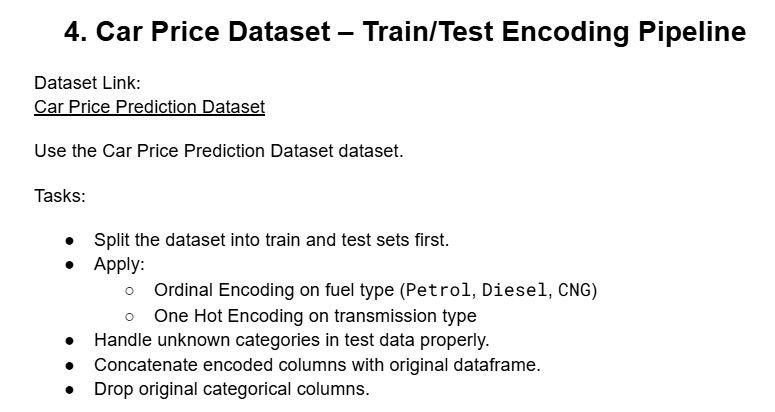

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [19]:
df = pd.read_csv("CarPrice.csv")

df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [20]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
oe = OrdinalEncoder(
    categories=[["Petrol", "Diesel", "CNG"]],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train["fuel"] = oe.fit_transform(X_train[["fueltype"]])
X_test["fuel"] = oe.transform(X_test[["fueltype"]])

In [29]:
ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
).set_output(transform="pandas")

asp_train = ohe.fit_transform(X_train[["aspiration"]])
asp_test = ohe.transform(X_test[["aspiration"]])

In [30]:
# 6. Concatenate
X_train = pd.concat([X_train, fuel_train, asp_train], axis=1)
X_test = pd.concat([X_test, fuel_test, asp_test], axis=1)

# 7. Drop original categorical columns
X_train = X_train.drop(["fueltype", "aspiration"], axis=1)
X_test = X_test.drop(["fueltype", "aspiration"], axis=1)


In [31]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

X_train.head()

Train Shape: (164, 26)
Test Shape: (41, 26)


,car_ID,symboling,CarName,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,fuel,aspiration_std,aspiration_turbo
66,67,0,mazda rx-7 gs,four,sedan,rwd,front,104.9,175.0,66.1,...,3.43,3.64,22.0,72,4200,31,39,-1.0,1.0,0.0
111,112,0,peugeot 504,four,sedan,rwd,front,107.9,186.7,68.4,...,3.46,2.19,8.4,95,5000,19,24,-1.0,1.0,0.0
153,154,0,toyota corona hardtop,four,wagon,fwd,front,95.7,169.7,63.6,...,3.05,3.03,9.0,62,4800,31,37,-1.0,1.0,0.0
96,97,1,nissan latio,four,sedan,fwd,front,94.5,165.3,63.8,...,3.15,3.29,9.4,69,5200,31,37,-1.0,1.0,0.0
38,39,0,honda civic 1300,two,hatchback,fwd,front,96.5,167.5,65.2,...,3.15,3.58,9.0,86,5800,27,33,-1.0,1.0,0.0
